In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv("test.csv")

In [ ]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

### Age is Null So compare Age with other Variable (Find relationship) to decide weather to ditch or fill the age colom

In [ ]:
age_corr = df.corr(numeric_only=True)["Age"].sort_values()
age_corr

Pclass        -0.492143
SibSp         -0.091587
Parch         -0.061249
PassengerId   -0.034102
Fare           0.337932
Age            1.000000
Name: Age, dtype: float64

In [ ]:
corr_matrix = age_corr.to_frame(name="Correlation with Age")
corr_matrix

,Correlation with Age
Pclass,-0.492143
SibSp,-0.091587
Parch,-0.061249
PassengerId,-0.034102
Fare,0.337932
Age,1.000000


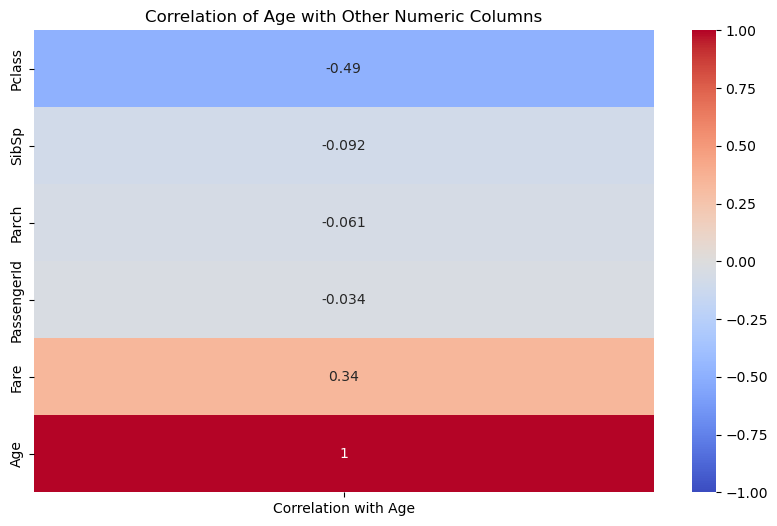

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation of Age with Other Numeric Columns")
plt.show()

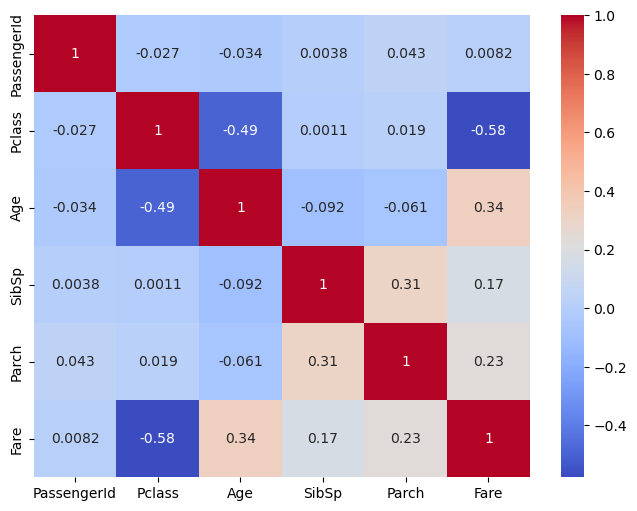

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Age and Pclass is showing good relation lets plot

<Axes: xlabel='Age', ylabel='Pclass'>

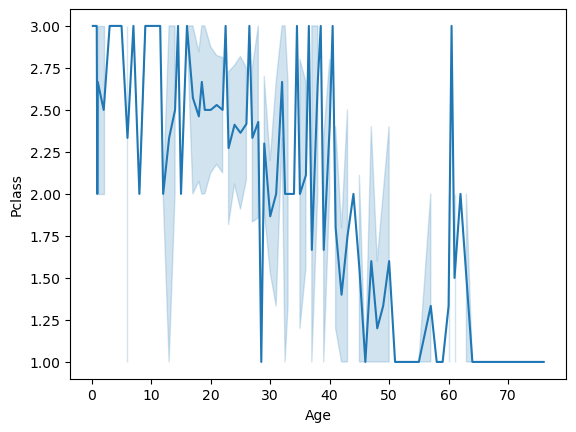

In [ ]:
sns.lineplot(x = "Age", y = "Pclass", data=df)

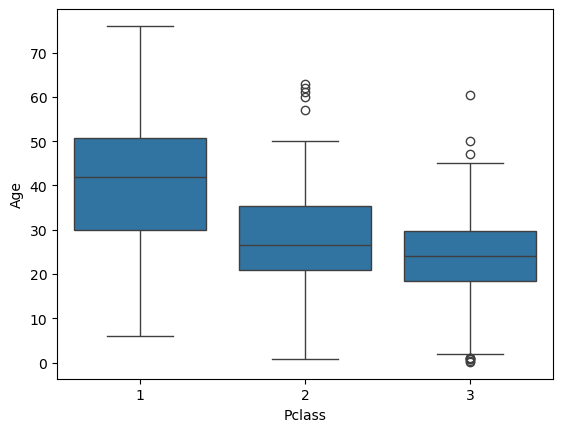

In [ ]:
sns.boxplot(x="Pclass", y="Age", data=df)
plt.show()

In [ ]:
df["Age"] = df["Age"].fillna(
    df.groupby("Pclass")["Age"].transform("median")
)

In [ ]:
df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

### Age is now filled but there is a Fare and cabin which are still null

### Since Fare and Pclass highest correlation lets fill

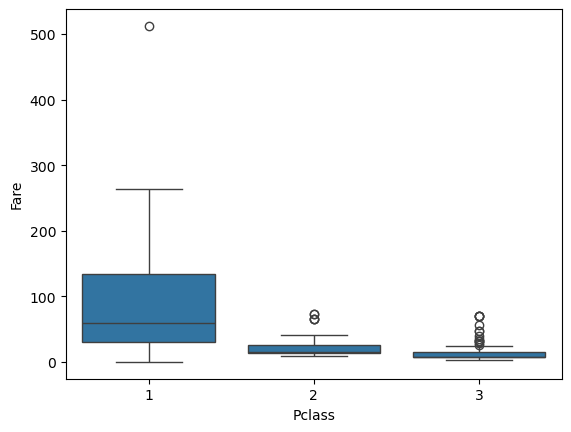

In [ ]:
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.show()

In [ ]:
df[df["Fare"].isna()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [ ]:
df["Fare"] = df["Fare"].fillna(
    df.groupby("Pclass")["Fare"].transform("median")
)

In [ ]:
df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64

### Now lets check cabin

In [ ]:
df["Cabin"].unique()

array([nan, 'B45', 'E31', 'B57 B59 B63 B66', 'B36', 'A21', 'C78', 'D34',
       'D19', 'A9', 'D15', 'C31', 'C23 C25 C27', 'F G63', 'B61', 'C53',
       'D43', 'C130', 'C132', 'C101', 'C55 C57', 'B71', 'C46', 'C116',
       'F', 'A29', 'G6', 'C6', 'C28', 'C51', 'E46', 'C54', 'C97', 'D22',
       'B10', 'F4', 'E45', 'E52', 'D30', 'B58 B60', 'E34', 'C62 C64',
       'A11', 'B11', 'C80', 'F33', 'C85', 'D37', 'C86', 'D21', 'C89',
       'F E46', 'A34', 'D', 'B26', 'C22 C26', 'B69', 'C32', 'B78',
       'F E57', 'F2', 'A18', 'C106', 'B51 B53 B55', 'D10 D12', 'E60',
       'E50', 'E39 E41', 'B52 B54 B56', 'C39', 'B24', 'D28', 'B41', 'C7',
       'D40', 'D38', 'C105'], dtype=object)

In [ ]:
df["Cabin"].isna().mean()*100

np.float64(78.22966507177034)

In [ ]:
df.drop('Cabin',axis=1,inplace=True)

### Dropping Cabin since it is mostly null

In [ ]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


### Mapping Categorical value to numberes

In [ ]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,S


In [ ]:
df["Embarked"].unique()
df["Embarked"] = df["Embarked"].map({
    "C":0,
    "Q":1,
    "S":2
})

df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,2
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,1
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,2
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,2


### Handling Outliers

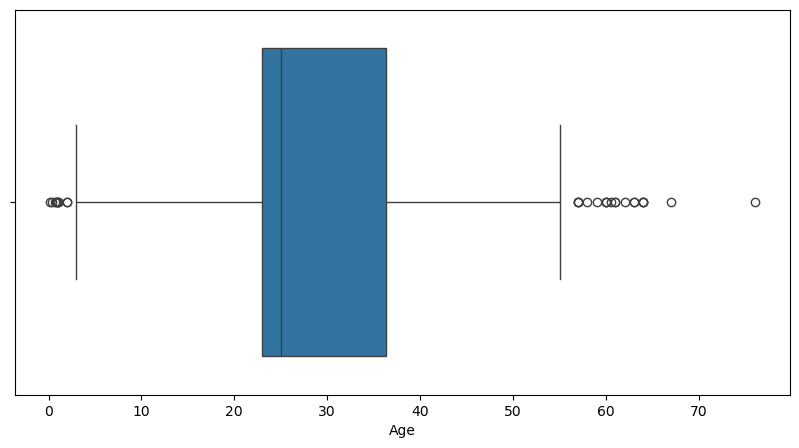

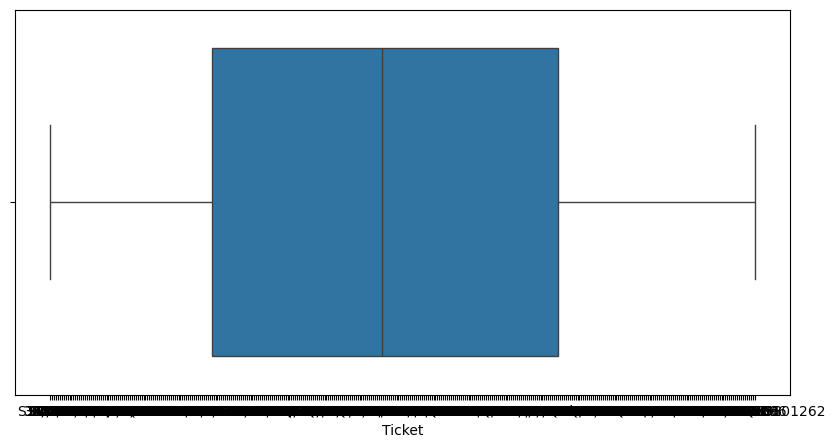

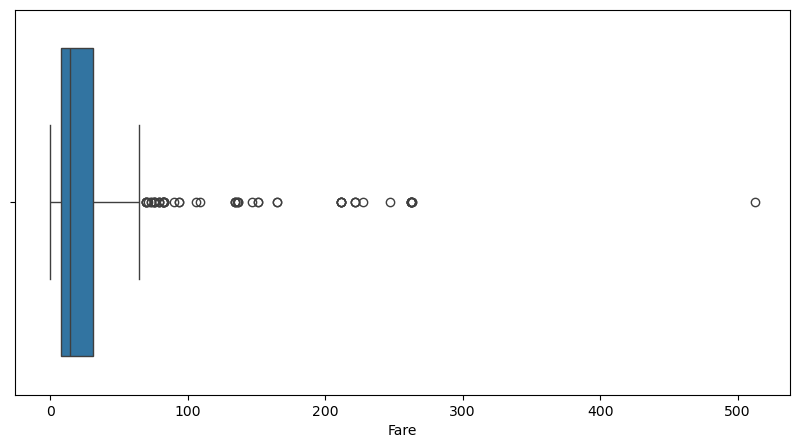

In [ ]:
numerical_colum = ["Age", "Ticket", "Fare"]

for i in numerical_colum:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[i])
    plt.show()

### Fare has biggest outlier

### So we are using log1p() to get it closer to mean

### The reason being is outlier should not dominate the Data

In [ ]:
df["Fare"] = np.log1p(df["Fare"]) 

<Axes: xlabel='Fare'>

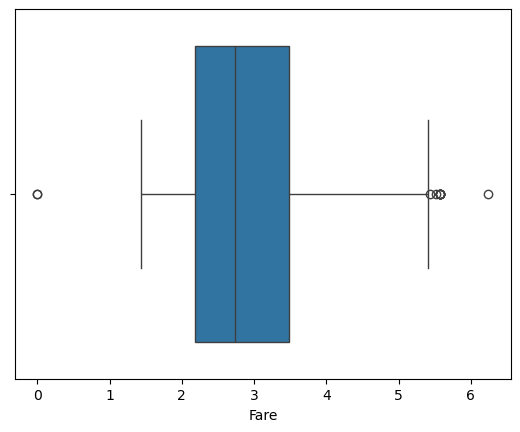

In [ ]:
sns.boxplot(x=df["Fare"])